## Group Project 1
## Submitted by: Vikas Gautam, Vahid Nikoofard

## Date: 24/4/2025

# Setting Up

In [159]:
import pandas as pd
import numpy as np
from datetime import datetime
import statsmodels.api as sm
import yfinance as yf
import matplotlib.cm as cm
import pandas_datareader.data as web
from statsmodels.regression.rolling import RollingOLS

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize

from scipy.signal import savgol_filter
from sklearn.linear_model import (
    LinearRegression,
    HuberRegressor,
    Ridge,
    Lasso,
    ElasticNet,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


This `regression()` function is a generic function for fitting and comparing a family of factor‐based return models (FF3 or FF5, with optional `macro` data) using any of five regression methods—ordinary least squares, robust Huber, Ridge, Lasso, or ElasticNet— via a single, consistent interface.

Depending on the `train_test_division` flag, it either performs a one‐off “simple” split (fit once on the first part of the data and test on the remainder) or a “rolling” division that refits on a fixed‐length window at each step. In the rolling case, it collects the time‐series of estimated factor loadings and applies a causal Savitzky–Golay filter to smooth out estimation noise, then uses the final smoothed loadings for out‐of‐sample prediction.

By z-scoring inputs, automatically adding any remaining DataFrame columns when `macro=True`, and exposing hyperparameters for regularization strength, smoothing window, and model choice, the function makes it easy to do the benchmarking on how different estimation techniques and data sets affect the factor exposures and forecast performance.

We will use this function in different steps of the project.

In [160]:
def regression(
    df: pd.DataFrame,
    method: str = 'ols',
    factors: str = 'ff3',
    macro: bool = False,
    train_test_division: str = 'simple',
    train_test_ratio: float = 0.8,
    window: int = 60,
    scale: bool = True,
    max_iter: int = 5000,
    savgol_window: int = 60,
    savgol_polyorder: int = 3,
    reg_params: dict = None,
):
    """
    Generic factor regression for FF3/FF5 (+ macro) using a variety of sklearn estimators.

    Parameters
    ----------
    df : DataFrame
        Must contain factor columns and 'Excess Return'.
    method : {'ols','huber','ridge','lasso','elasticnet'}
    factors : {'ff3','ff5'}
    macro : bool
        If True, appends ['DGS10_chg','DGS2_chg','DCOILWTICO_chg','TermSpread_chg'].
    train_test_division : {'simple','rolling'}
    train_test_ratio : float
    window : int
        Rolling window size.
    scale : bool
        If True, z-score all factors.
    max_iter : int
        Passed to HuberRegressor (ignored by others).
    savgol_window : int
        Window length for Savitzky–Golay (rolling only).
    savgol_polyorder : int
    reg_params : dict, optional
        e.g. {'ridge': {'alpha':2.0}, 'elasticnet': {'l1_ratio':0.7}}

    Returns
    -------
    simple  -> (pd.Series betas, float rmse, float r2)
    rolling -> (pd.DataFrame raw_betas_over_time, float rmse, float r2)
    """
    # 1) choose model factory and default params
    regressors = {
        'ols':        (LinearRegression, {}),
        'huber':      (HuberRegressor,    {'max_iter': max_iter}),
        'ridge':      (Ridge,             {'alpha': 1.0}),
        'lasso':      (Lasso,             {'alpha': 1.0}),
        'elasticnet': (ElasticNet,        {'alpha': 1.0, 'l1_ratio': 0.5}),
    }
    if method not in regressors:
        raise ValueError(f"Unknown method '{method}'. Valid: {list(regressors)}")
    ModelClass, default_kwargs = regressors[method]

    # override defaults if user passed reg_params
    params = default_kwargs.copy()
    if reg_params and method in reg_params:
        params.update(reg_params[method])

    # 2) build feature list
        # 2) build feature list
    if factors == 'ff3':
        feats = ['Mkt-RF', 'SMB', 'HML']
    elif factors == 'ff5':
        feats = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
    else:
        raise ValueError("factors must be 'ff3' or 'ff5'")

    if macro:
        # add every column in df that's not already in feats and not the target
        extras = [
            col for col in df.columns
            if col not in feats + ['Excess Return']
        ]
        feats += extras

    # 3) extract X, y
    X = df[feats].copy()
    y = df['Excess Return'].copy()

    # 4) optional scaling
    if scale:
        scaler = StandardScaler().fit(X)
        X[:]    = scaler.transform(X)

    # 5) split train/test once
    split = int(len(df) * train_test_ratio)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # 6) SIMPLE regime
    if train_test_division == 'simple':
        model = ModelClass(**params)
        model.fit(X_train, y_train)

        betas  = pd.Series(model.coef_, index=feats, name=method)
        y_pred = model.predict(X_test)
        rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
        r2     = r2_score(y_test, y_pred)
        return betas, rmse, r2

    # 7) ROLLING regime
    elif train_test_division == 'rolling':
        n_splits = len(X_train) - window
        if n_splits <= 0:
            raise ValueError("window too large for training data")

        tscv = TimeSeriesSplit(
            n_splits       = n_splits,
            max_train_size = window,
            test_size      = 1,
            gap            = 0,
        )

        model          = ModelClass(**params)
        betas_list     = []
        intercepts_list = []

        # collect raw rolling fits
        for train_idx, _ in tscv.split(X_train):
            X_w, y_w = X_train.iloc[train_idx], y_train.iloc[train_idx]
            model.fit(X_w, y_w)
            betas_list.append(model.coef_.copy())
            # intercept_attr may differ by regressor name:
            intercepts_list.append(
                getattr(model, 'intercept_', 0.0)
            )

        idx      = X_train.index[window:]
        betas_df = pd.DataFrame(betas_list, index=idx, columns=feats)
        ints_s   = pd.Series(intercepts_list, index=idx, name='intercept')

        # causal SavGol smoothing of each coefficient series
        n_rows = len(betas_df)
        wl = min(savgol_window, n_rows if n_rows%2 else n_rows-1)
        if wl <= savgol_polyorder:
            raise ValueError(
                f"savgol_window ({savgol_window}) must be > polyorder "
                f"({savgol_polyorder}) and ≤ #estimates ({n_rows})"
            )

        betas_smooth = betas_df.apply(
            lambda col: savgol_filter(col.values, wl, savgol_polyorder, mode='interp'),
            axis=0, result_type='expand'
        )
        betas_smooth.index = idx

        ints_smooth = pd.Series(
            savgol_filter(ints_s.values, wl, savgol_polyorder, mode='interp'),
            index=idx, name='intercept'
        )

        # final parameters for test prediction
        beta_final      = betas_smooth.iloc[-1].values
        intercept_final = ints_smooth.iloc[-1]

        # predict & score
        y_pred = X_test.values @ beta_final + intercept_final
        rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
        r2     = r2_score(y_test, y_pred)

        return betas_df, rmse, r2

    else:
        raise ValueError("train_test_division must be 'simple' or 'rolling'")


# Step 2

## download the factors data

In [161]:
# === Step: Download FF3 daily data ===
ff5_url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip'
ff5_raw = pd.read_csv(ff5_url, skiprows=3,index_col=0)
ff5_raw = ff5_raw.rename_axis("Date").reset_index()

correcting the `Date` column format

In [162]:
ff5_raw["Date"] = ff5_raw["Date"].astype(str)

ff5_raw['Date'] = pd.to_datetime(ff5_raw['Date'], format='%Y%m%d')
ff5 = ff5_raw.set_index('Date')   # convert to decimal returns
ff5.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-01,-0.67,0.02,-0.35,0.03,0.13,0.012
1963-07-02,0.79,-0.28,0.28,-0.08,-0.21,0.012
1963-07-03,0.63,-0.18,-0.10,0.13,-0.25,0.012
1963-07-05,0.40,0.09,-0.28,0.07,-0.30,0.012
1963-07-08,-0.63,0.07,-0.20,-0.27,0.06,0.012


## download TESLA data and Economic data

In [163]:
# Define start and end dates
start_date = ff5.index[-1] - pd.Timedelta(days=3*365)
end_date = ff5.index[-1]

# Download S&P 500 (^GSPC is the Yahoo ticker for S&P 500 index)
tsla = yf.download('TSLA', start=start_date, end=end_date)
tsla.columns = tsla.columns.get_level_values(0)
tsla['Daily Return'] = tsla['Close'].pct_change()
# Show the first few rows
tsla.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,
2022-01-03,399.926666,400.356659,378.679993,382.583344,103931400,NaN
2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300,-0.041833
2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800,-0.053471
2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600,-0.021523
2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700,-0.035447


## download Portfolio data

In [164]:
# === Step 1: Select 5 stocks and download data ===
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
start = ff5.index[-1] - pd.Timedelta(days=3*365)
end = ff5.index[-1]
data = yf.download(tickers, start=start, end=end)['Close']
returns1 = data.pct_change().dropna()
returns1.head(3)

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOG,MSFT,TSLA
Date,,,,,
2022-01-04,-0.012692,-0.016916,-0.004535,-0.017147,-0.041833
2022-01-05,-0.026600,-0.018893,-0.046830,-0.038388,-0.053471
2022-01-06,-0.016693,-0.006711,-0.000745,-0.007902,-0.021523


In [165]:
# === Step 7: Print optimal weights ===
optimal_weights1 = [0.2, 0.2, 0.2, 0.2, 0.2]
opt_df1 = pd.DataFrame({'Stock': tickers, 'Weight': optimal_weights1})
print("\n=== Optimal Portfolio Weights ===")
print(opt_df1)


=== Optimal Portfolio Weights ===
  Stock  Weight
0  AAPL     0.2
1  MSFT     0.2
2  GOOG     0.2
3  AMZN     0.2
4  TSLA     0.2


In [166]:
portfolio_returns1 = returns1.dot(optimal_weights1)

## Downloading the marco economical data

In [167]:
# === Step : Set the date range ===
start = ff5.index[-1] - pd.Timedelta(days=3*365)
end = ff5.index[-1]
df5=pd.DataFrame()
# === Step : Fetch data from FRED ===
macro_ids = ["DGS10", "FEDFUNDS", "VIXCLS", 'DGS2', 'DCOILWTICO']      # 10-yr yield, EFFR, VIX, 2-yr yield, Crude Oil

macro = (
    web.DataReader(macro_ids, "fred", start, end)
      .astype(float)
      .ffill()                    # fill occasional missing business days
      .div(100.0)                 # % → decimal
)

macro['TermSpread'] = macro['DGS10'] - macro['DGS2']
df5 = pd.merge(ff5, macro, left_index=True, right_index=True).dropna()
df5=pd.merge(df5, tsla['Daily Return'], left_index=True, right_index=True).dropna()
df5.dropna(inplace=True)


df5.tail()


,Mkt-RF,SMB,HML,RMW,CMA,RF,DGS10,FEDFUNDS,VIXCLS,DGS2,DCOILWTICO,TermSpread,Daily Return
2024-12-23,0.61,-0.85,-0.19,0.28,0.66,0.017,0.0459,0.0448,0.1678,0.0430,0.6950,0.0029,0.022657
2024-12-24,1.11,-0.12,-0.05,-0.13,-0.37,0.017,0.0459,0.0448,0.1427,0.0429,0.7087,0.0030,0.073572
2024-12-26,0.02,1.09,-0.19,-0.44,0.35,0.017,0.0458,0.0448,0.1473,0.0430,0.7038,0.0028,-0.017630
2024-12-27,-1.17,-0.44,0.56,0.41,0.03,0.017,0.0462,0.0448,0.1595,0.0431,0.7128,0.0031,-0.049479
2024-12-30,-1.09,0.24,0.74,0.55,0.14,0.017,0.0455,0.0448,0.1740,0.0424,0.7173,0.0031,-0.033012


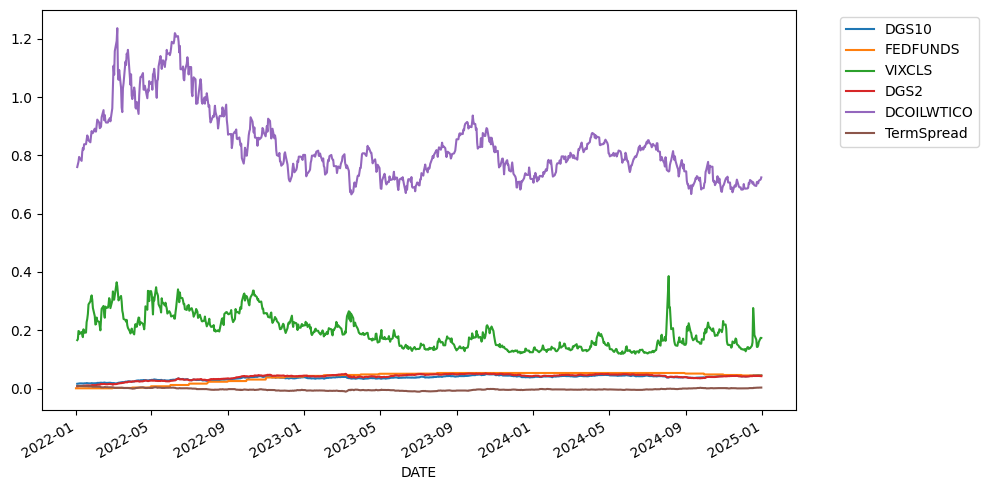

In [168]:
macro.plot(figsize=(10, 5))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # Experiment with the pad value

plt.show()

### Adjust Excess Return = Target Return - risk free Rate

In [169]:

# ---- decide which series to difference ----
to_diff   = ["DGS10", 'DGS2', 'TermSpread', 'DCOILWTICO',"VIXCLS"]
stationary = ["FEDFUNDS"]
df5[to_diff] = df5[to_diff].diff()
df5.columns = [c + ("_chg" if c in to_diff else "") for c in df5]
df5.dropna(inplace=True)


df5['Excess Return']= df5['Daily Return']-df5['RF']
df5.drop(['FEDFUNDS','Daily Return'], axis=1, inplace=True)
df5.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg,Excess Return
2022-01-05,-2.28,-0.94,2.59,1.39,1.25,0.0,0.0005,0.0282,0.0006,0.0083,-0.0001,-0.053471
2022-01-06,0.00,0.38,1.75,-0.56,-0.01,0.0,0.0002,-0.0012,0.0005,0.0164,-0.0003,-0.021523
2022-01-07,-0.48,-0.96,2.02,-0.12,0.85,0.0,0.0003,-0.0085,-0.0001,-0.0047,0.0004,-0.035447
2022-01-10,-0.15,-0.30,-0.28,-0.05,-0.37,0.0,0.0002,0.0064,0.0005,-0.0089,-0.0003,0.030342
2022-01-11,1.10,-0.20,-0.28,-1.25,0.37,0.0,-0.0003,-0.0099,-0.0002,0.0306,-0.0001,0.005935


In [170]:
ff1=df5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'DGS10_chg','VIXCLS_chg','RF',\
        'DGS2_chg', 'DCOILWTICO_chg', 'TermSpread_chg']]
ff1=ff1[start:end]
ff1=pd.DataFrame(ff1)
ff1.head()


,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,RF,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
2022-01-05,-2.28,-0.94,2.59,1.39,1.25,0.0005,0.0282,0.0,0.0006,0.0083,-0.0001
2022-01-06,0.00,0.38,1.75,-0.56,-0.01,0.0002,-0.0012,0.0,0.0005,0.0164,-0.0003
2022-01-07,-0.48,-0.96,2.02,-0.12,0.85,0.0003,-0.0085,0.0,-0.0001,-0.0047,0.0004
2022-01-10,-0.15,-0.30,-0.28,-0.05,-0.37,0.0002,0.0064,0.0,0.0005,-0.0089,-0.0003
2022-01-11,1.10,-0.20,-0.28,-1.25,0.37,-0.0003,-0.0099,0.0,-0.0002,0.0306,-0.0001


In [171]:
# === Step 4: Align and merge ===
portfolio_returns1.name = 'Portfolio_Return'
portfolio_returns1.index = pd.to_datetime(portfolio_returns1.index)
df1 = pd.merge(portfolio_returns1,ff1, left_index=True, right_index=True).dropna()
df1['Excess Return'] = df1['Portfolio_Return'] - df1['RF']
df1 = df1.drop(columns=['Portfolio_Return', 'RF'], errors='ignore')
df2=df5.copy()
df5=df5.drop(columns=['RF'], errors='ignore')
df1.head()

,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg,Excess Return
2022-01-05,-2.28,-0.94,2.59,1.39,1.25,0.0005,0.0282,0.0006,0.0083,-0.0001,-0.036836
2022-01-06,0.00,0.38,1.75,-0.56,-0.01,0.0002,-0.0012,0.0005,0.0164,-0.0003,-0.010715
2022-01-07,-0.48,-0.96,2.02,-0.12,0.85,0.0003,-0.0085,-0.0001,-0.0047,0.0004,-0.008442
2022-01-10,-0.15,-0.30,-0.28,-0.05,-0.37,0.0002,0.0064,0.0005,-0.0089,-0.0003,0.007215
2022-01-11,1.10,-0.20,-0.28,-1.25,0.37,-0.0003,-0.0099,-0.0002,0.0306,-0.0001,0.011879


# Step 3

In [172]:
df5.head()

,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg,Excess Return
2022-01-05,-2.28,-0.94,2.59,1.39,1.25,0.0005,0.0282,0.0006,0.0083,-0.0001,-0.053471
2022-01-06,0.00,0.38,1.75,-0.56,-0.01,0.0002,-0.0012,0.0005,0.0164,-0.0003,-0.021523
2022-01-07,-0.48,-0.96,2.02,-0.12,0.85,0.0003,-0.0085,-0.0001,-0.0047,0.0004,-0.035447
2022-01-10,-0.15,-0.30,-0.28,-0.05,-0.37,0.0002,0.0064,0.0005,-0.0089,-0.0003,0.030342
2022-01-11,1.10,-0.20,-0.28,-1.25,0.37,-0.0003,-0.0099,-0.0002,0.0306,-0.0001,0.005935


##  FF3 : Regression

In [173]:
methods        = ['ols','huber','ridge','lasso','elasticnet']
regimes        = ['simple','rolling']
macro_options  = [False, True]

results = []

for method in methods:
    for regime in regimes:
        for macro in macro_options:
            name = f"{method}_{regime}_ff3" + ("_macro" if macro else "")

            # call your unified function
            betas_all, rmse, r2 = regression(
                df5,
                method               = method,
                factors              = 'ff3',
                macro                = macro,
                train_test_division  = regime,
                train_test_ratio     = 0.8,
                window               = 60,
                scale                = True,
                savgol_window        = 60,
                savgol_polyorder     = 3,
                # you can also pass reg_params={'ridge':{'alpha':2.0},...} here if desired
            )

            # for "rolling", extract just the last row of betas
            if regime == 'rolling':
                betas = betas_all.iloc[-1]
            else:
                betas = betas_all

            results.append((name, betas, rmse, r2))

# now unpack into DataFrames
names, betas_list, rmses, r2s = zip(*results)

# 1) betas_df: each row = one model, columns = factors
betas_ff3 = pd.DataFrame(betas_list, index=names)

# 2) metrics_df: RMSE & R²
metrics_ff3 = pd.DataFrame({
    'rmse': rmses,
    'r2':   r2s
}, index=names).sort_values('r2', ascending=False)

# inspect
print(betas_ff3.shape)    # (20, p)
print(metrics_ff3.shape)  # (20, 2)
metrics_ff3.head()

(20, 10)
(20, 2)


,rmse,r2
huber_simple_ff3,0.036212,0.274668
ols_simple_ff3,0.036229,0.273955
ridge_simple_ff3,0.036234,0.273760
huber_simple_ff3_macro,0.036266,0.272477
ridge_simple_ff3_macro,0.036411,0.266672


In [174]:
metrics_ff3.head(-6)

,rmse,r2
huber_simple_ff3,0.036212,0.274668
ols_simple_ff3,0.036229,0.273955
ridge_simple_ff3,0.036234,0.273760
huber_simple_ff3_macro,0.036266,0.272477
ridge_simple_ff3_macro,0.036411,0.266672
ols_simple_ff3_macro,0.036411,0.266658
ols_rolling_ff3,0.038127,0.195909
ridge_rolling_ff3,0.038238,0.191206
ridge_rolling_ff3_macro,0.039326,0.144551
ols_rolling_ff3_macro,0.039431,0.139949


In [175]:
betas_ff3.head(-6)


,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
ols_simple_ff3,0.017012,0.003461,-0.006765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ols_simple_ff3_macro,0.013401,0.000001,0.000599,-0.005984,-0.008619,0.000121,-0.000725,0.001159,0.000532,-0.001740
ols_rolling_ff3,0.015276,0.007066,-0.003391,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ols_rolling_ff3_macro,0.011106,0.010422,-0.002051,0.007424,-0.005721,-0.003631,-0.003222,0.001061,0.000110,-0.006999
huber_simple_ff3,0.017419,0.003839,-0.005568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber_simple_ff3_macro,0.014538,0.000474,-0.000202,-0.006196,-0.005900,0.000796,-0.000441,0.001311,0.000561,-0.001013
huber_rolling_ff3,0.015993,0.005920,0.000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber_rolling_ff3_macro,0.010501,0.008122,0.001861,0.001536,-0.007458,-0.002367,-0.000231,-0.000302,0.001350,-0.002922
ridge_simple_ff3,0.016986,0.003460,-0.006766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ridge_simple_ff3_macro,0.013348,0.000021,0.000561,-0.005966,-0.008599,0.000121,-0.000773,0.001158,0.000541,-0.001738


In [176]:
methods        = ['ols','huber','ridge','lasso','elasticnet']
regimes        = ['simple','rolling']
macro_options  = [False, True]

results = []

for method in methods:
    for regime in regimes:
        for macro in macro_options:
            name = f"{method}_{regime}_ff3" + ("_macro" if macro else "")

            # call your unified function
            betas_all, rmse, r2 = regression(
                df1,
                method               = method,
                factors              = 'ff3',
                macro                = macro,
                train_test_division  = regime,
                train_test_ratio     = 0.8,
                window               = 60,
                scale                = True,
                savgol_window        = 60,
                savgol_polyorder     = 3,
                # you can also pass reg_params={'ridge':{'alpha':2.0},...} here if desired
            )

            # for "rolling", extract just the last row of betas
            if regime == 'rolling':
                betas = betas_all.iloc[-1]
            else:
                betas = betas_all

            results.append((name, betas, rmse, r2))

# now unpack into DataFrames
names_2, betas_list_2, rmses_2, r2s_2 = zip(*results)

# 1) betas_df: each row = one model, columns = factors
betas_ff3_2 = pd.DataFrame(betas_list_2, index=names)

# 2) metrics_df: RMSE & R²
metrics_ff3_2 = pd.DataFrame({
    'rmse': rmses_2,
    'r2':   r2s_2
}, index=names).sort_values('r2', ascending=False)

# inspect
print(betas_ff3_2.shape)    # (20, p)
print(metrics_ff3_2.shape)  # (20, 2)
metrics_ff3_2.head()

(20, 10)
(20, 2)


,rmse,r2
huber_simple_ff3_macro,0.010056,0.611003
ols_rolling_ff3,0.010086,0.608637
ridge_rolling_ff3,0.010114,0.606530
huber_rolling_ff3,0.010141,0.604356
ridge_simple_ff3_macro,0.010290,0.592667


In [177]:
metrics_ff3_2.head(-6)

,rmse,r2
huber_simple_ff3_macro,0.010056,0.611003
ols_rolling_ff3,0.010086,0.608637
ridge_rolling_ff3,0.010114,0.606530
huber_rolling_ff3,0.010141,0.604356
ridge_simple_ff3_macro,0.010290,0.592667
ols_simple_ff3_macro,0.010294,0.592395
ridge_rolling_ff3_macro,0.010417,0.582537
huber_simple_ff3,0.010625,0.565720
ols_rolling_ff3_macro,0.010770,0.553784
ols_simple_ff3,0.010873,0.545252


In [178]:
betas_ff3_2.head(-6)


,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
ols_simple_ff3,0.014299,-0.001454,-0.004224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ols_simple_ff3_macro,0.013504,-0.001871,-0.002494,-0.000498,-0.002705,0.000069,0.000134,0.000296,0.000495,-0.000389
ols_rolling_ff3,0.013803,0.001478,-0.004698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ols_rolling_ff3_macro,0.013601,0.002067,-0.004537,0.002288,-0.001393,-0.000801,0.001211,-0.000575,-0.000806,-0.000207
huber_simple_ff3,0.014113,-0.001174,-0.004519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber_simple_ff3_macro,0.013518,-0.001561,-0.002615,-0.000402,-0.002938,-0.000051,0.000661,0.000263,0.000082,-0.000508
huber_rolling_ff3,0.013339,0.001604,-0.004823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber_rolling_ff3_macro,0.011867,0.002457,-0.004250,0.002166,-0.002410,-0.001050,0.000954,-0.000598,-0.001920,-0.000529
ridge_simple_ff3,0.014274,-0.001445,-0.004229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ridge_simple_ff3_macro,0.013438,-0.001860,-0.002496,-0.000497,-0.002720,0.000068,0.000079,0.000293,0.000501,-0.000387


# Step 4

## FF5 Regression

In [179]:
# first, your unified regression() from before
# from your_module import regression

methods        = ['ols','huber','ridge','lasso','elasticnet']
regimes        = ['simple','rolling']
macro_options  = [False, True]

results = []

for method in methods:
    for regime in regimes:
        for macro in macro_options:
            name = f"{method}_{regime}_ff5" + ("_macro" if macro else "")

            # call your unified function
            betas_all, rmse, r2 = regression(
                df5,
                method               = method,
                factors              = 'ff5',
                macro                = macro,
                train_test_division  = regime,
                train_test_ratio     = 0.8,
                window               = 60,
                scale                = True,
                savgol_window        = 11,
                savgol_polyorder     = 3,
                # you can also pass reg_params={'ridge':{'alpha':2.0},...} here if desired
            )

            # for "rolling", extract just the last row of betas
            if regime == 'rolling':
                betas = betas_all.iloc[-1]
            else:
                betas = betas_all

            results.append((name, betas, rmse, r2))

# now unpack into DataFrames
names, betas_list, rmses, r2s = zip(*results)

# 1) betas_df: each row = one model, columns = factors
betas_ff5 = pd.DataFrame(betas_list, index=names)

# 2) metrics_df: RMSE & R²
metrics_ff5 = pd.DataFrame({
    'rmse': rmses,
    'r2':   r2s
}, index=names).sort_values('r2', ascending=False)

# inspect
print(betas_ff5.shape)    # (20, p)
print(metrics_ff5.shape)  # (20, 2)
betas_ff5.head()
metrics_ff5.head()


(20, 10)
(20, 2)


,rmse,r2
huber_simple_ff5_macro,0.036266,0.272477
ridge_simple_ff5_macro,0.036411,0.266672
ols_simple_ff5_macro,0.036411,0.266658
huber_simple_ff5,0.036513,0.262535
ols_simple_ff5,0.036754,0.252774


In [180]:
metrics_ff5.head(-6)


,rmse,r2
huber_simple_ff5_macro,0.036266,0.272477
ridge_simple_ff5_macro,0.036411,0.266672
ols_simple_ff5_macro,0.036411,0.266658
huber_simple_ff5,0.036513,0.262535
ols_simple_ff5,0.036754,0.252774
ridge_simple_ff5,0.036754,0.252760
ols_rolling_ff5,0.038866,0.164438
ridge_rolling_ff5,0.039030,0.157349
ridge_rolling_ff5_macro,0.039512,0.136407
ols_rolling_ff5_macro,0.039524,0.135898


In [181]:
betas_ff5.head(-6)


,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
ols_simple_ff5,0.014044,-0.000302,0.001579,-0.006270,-0.008954,NaN,NaN,NaN,NaN,NaN
ols_simple_ff5_macro,0.013401,0.000001,0.000599,-0.005984,-0.008619,0.000121,-0.000725,0.001159,0.000532,-0.001740
ols_rolling_ff5,0.014386,0.010242,-0.003205,0.006804,-0.002673,NaN,NaN,NaN,NaN,NaN
ols_rolling_ff5_macro,0.011106,0.010422,-0.002051,0.007424,-0.005721,-0.003631,-0.003222,0.001061,0.000110,-0.006999
huber_simple_ff5,0.015071,-0.000017,0.000923,-0.006517,-0.006195,NaN,NaN,NaN,NaN,NaN
huber_simple_ff5_macro,0.014538,0.000474,-0.000202,-0.006196,-0.005900,0.000796,-0.000441,0.001311,0.000561,-0.001013
huber_rolling_ff5,0.012138,0.007953,0.002337,0.001454,-0.006306,NaN,NaN,NaN,NaN,NaN
huber_rolling_ff5_macro,0.010501,0.008122,0.001861,0.001536,-0.007458,-0.002367,-0.000231,-0.000302,0.001350,-0.002922
ridge_simple_ff5,0.014024,-0.000284,0.001539,-0.006256,-0.008925,NaN,NaN,NaN,NaN,NaN
ridge_simple_ff5_macro,0.013348,0.000021,0.000561,-0.005966,-0.008599,0.000121,-0.000773,0.001158,0.000541,-0.001738


In [182]:
# first, your unified regression() from before
# from your_module import regression

methods        = ['ols','huber','ridge','lasso','elasticnet']
regimes        = ['simple','rolling']
macro_options  = [False, True]

results = []

for method in methods:
    for regime in regimes:
        for macro in macro_options:
            name = f"{method}_{regime}_ff5" + ("_macro" if macro else "")

            # call your unified function
            betas_all, rmse, r2 = regression(
                df1,
                method               = method,
                factors              = 'ff5',
                macro                = macro,
                train_test_division  = regime,
                train_test_ratio     = 0.8,
                window               = 60,
                scale                = True,
                savgol_window        = 11,
                savgol_polyorder     = 3,
                # you can also pass reg_params={'ridge':{'alpha':2.0},...} here if desired
            )

            # for "rolling", extract just the last row of betas
            if regime == 'rolling':
                betas = betas_all.iloc[-1]
            else:
                betas = betas_all

            results.append((name, betas, rmse, r2))

# now unpack into DataFrames
names_2, betas_list_2, rmses_2, r2s_2 = zip(*results)

# 1) betas_df: each row = one model, columns = factors
betas_ff5_2 = pd.DataFrame(betas_list_2, index=names)

# 2) metrics_df: RMSE & R²
metrics_ff5_2 = pd.DataFrame({
    'rmse': rmses_2,
    'r2':   r2s_2
}, index=names).sort_values('r2', ascending=False)

# inspect
print(betas_ff5_2.shape)    # (20, p)
print(metrics_ff5_2.shape)  # (20, 2)
betas_ff5_2.head()
metrics_ff5_2.head()


(20, 10)
(20, 2)


,rmse,r2
ols_rolling_ff5,0.009872,0.625085
ridge_rolling_ff5,0.009995,0.615725
huber_simple_ff5,0.010002,0.615200
huber_simple_ff5_macro,0.010056,0.611003
ridge_rolling_ff5_macro,0.010144,0.604173


In [183]:
metrics_ff5_2.head(-6)

,rmse,r2
ols_rolling_ff5,0.009872,0.625085
ridge_rolling_ff5,0.009995,0.615725
huber_simple_ff5,0.010002,0.615200
huber_simple_ff5_macro,0.010056,0.611003
ridge_rolling_ff5_macro,0.010144,0.604173
huber_rolling_ff5,0.010169,0.602220
ols_rolling_ff5_macro,0.010170,0.602148
ridge_simple_ff5_macro,0.010290,0.592667
ols_simple_ff5_macro,0.010294,0.592395
ols_simple_ff5,0.010355,0.587546


In [184]:
betas_ff5_2.head(-6)


,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
ols_simple_ff5,0.013521,-0.002003,-0.002105,-0.000636,-0.002800,NaN,NaN,NaN,NaN,NaN
ols_simple_ff5_macro,0.013504,-0.001871,-0.002494,-0.000498,-0.002705,0.000069,0.000134,0.000296,0.000495,-0.000389
ols_rolling_ff5,0.013105,0.002692,-0.004368,0.002294,-0.001599,NaN,NaN,NaN,NaN,NaN
ols_rolling_ff5_macro,0.013601,0.002067,-0.004537,0.002288,-0.001393,-0.000801,0.001211,-0.000575,-0.000806,-0.000207
huber_simple_ff5,0.013183,-0.001544,-0.002426,-0.000354,-0.003045,NaN,NaN,NaN,NaN,NaN
huber_simple_ff5_macro,0.013518,-0.001561,-0.002615,-0.000402,-0.002938,-0.000051,0.000661,0.000263,0.000082,-0.000508
huber_rolling_ff5,0.011827,0.002997,-0.004298,0.001707,-0.002430,NaN,NaN,NaN,NaN,NaN
huber_rolling_ff5_macro,0.011867,0.002457,-0.004250,0.002166,-0.002410,-0.001050,0.000954,-0.000598,-0.001920,-0.000529
ridge_simple_ff5,0.013493,-0.001995,-0.002107,-0.000638,-0.002808,NaN,NaN,NaN,NaN,NaN
ridge_simple_ff5_macro,0.013438,-0.001860,-0.002496,-0.000497,-0.002720,0.000068,0.000079,0.000293,0.000501,-0.000387


# Step 5

## Plot daily factor Returns

<Figure size 800x600 with 0 Axes>

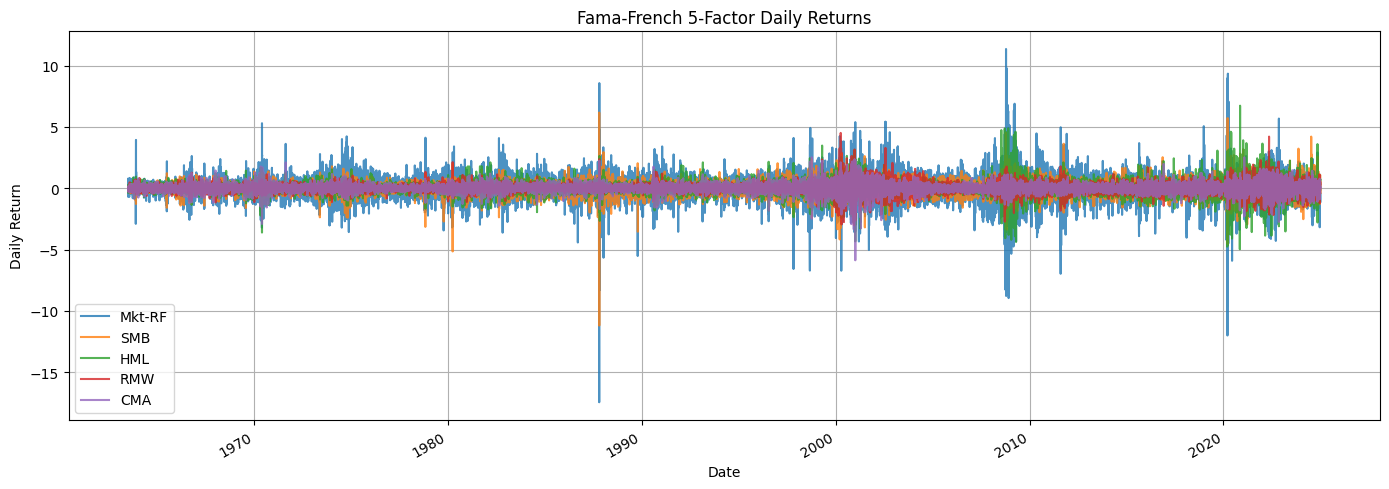

In [185]:
ff5_factors = ff5[['Mkt-RF', 'SMB', 'HML', 'RMW','CMA']]
# === Step : Plot ===
plt.figure(figsize=(8, 6))
ff5_factors.plot(title='Fama-French 5-Factor Daily Returns', figsize=(14, 5), alpha=0.8)
plt.ylabel('Daily Return')
plt.grid(True)
plt.tight_layout()
plt.show();

<ipython-input-186-201fcc1e3ba9>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(ff5_factors.columns))  # or 'viridis'


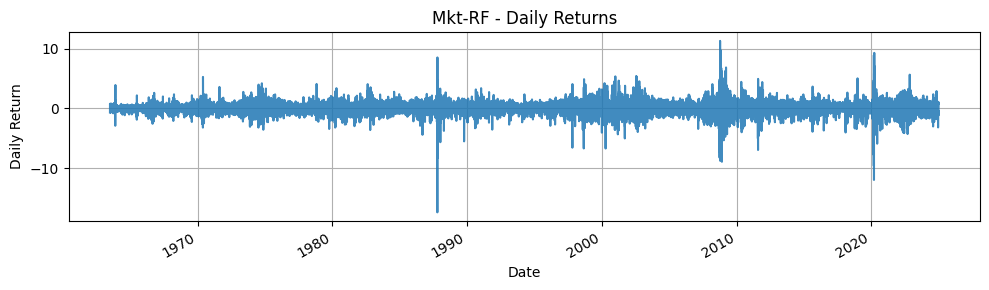

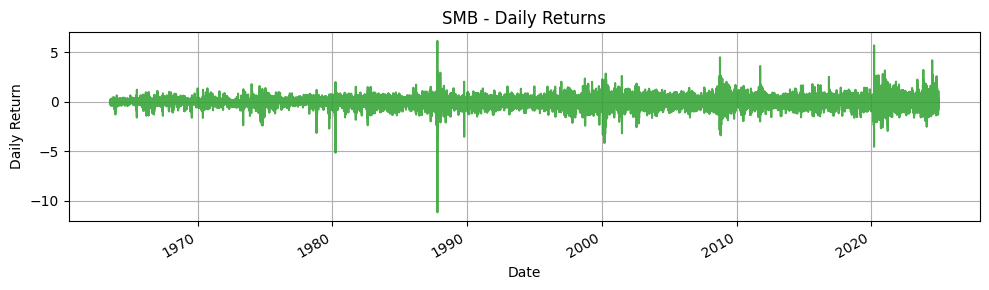

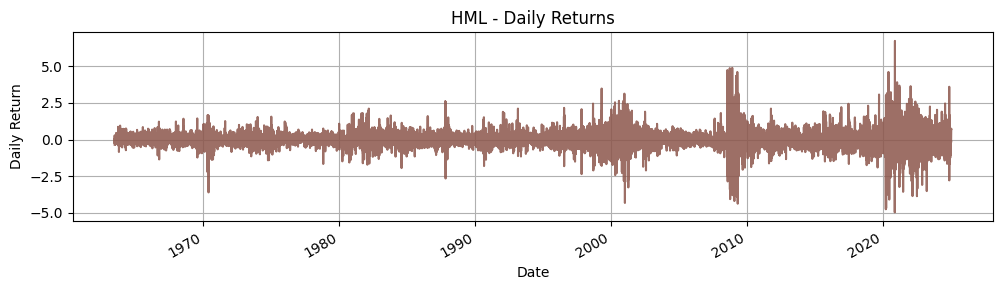

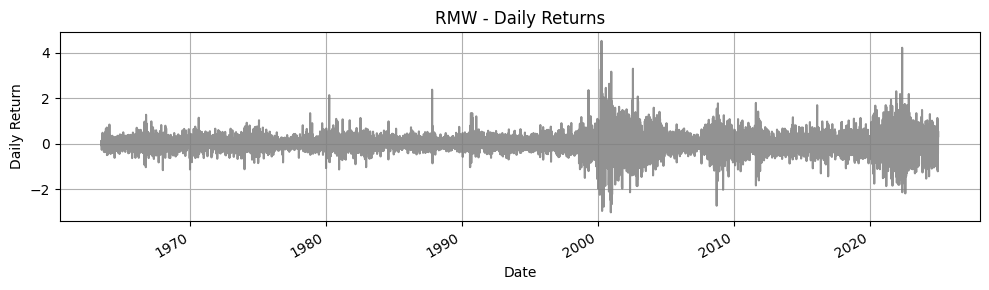

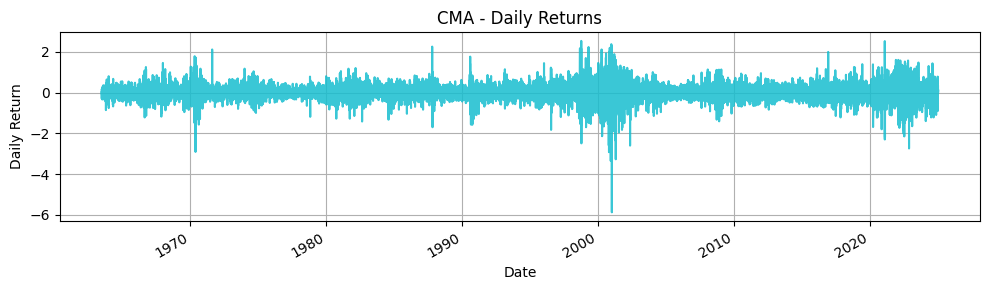

In [186]:
# Define your colormap (tab10 has 10 distinct colors, or use 'viridis' for a smooth gradient)
cmap = cm.get_cmap('tab10', len(ff5_factors.columns))  # or 'viridis'

# Plot each column in its own subplot with color based on column index
for idx, col in enumerate(ff5_factors.columns):
    plt.figure(figsize=(10, 3))
    color = cmap(idx)  # get color based on column index
    ff5_factors[col].plot(title=f'{col} - Daily Returns', color=color, alpha=0.85)
    plt.ylabel('Daily Return')
    plt.grid(True)
    plt.tight_layout()
    plt.show();


## Corrrelation and Covariance of Factors

In [187]:
corr_ff5 = ff5.corr()
# === Step 4: Display results ===
print("=== FF5 Factor Return Correlation Matrix ===")
print(corr_ff5.round(3))


=== FF5 Factor Return Correlation Matrix ===
        Mkt-RF    SMB    HML    RMW    CMA     RF
Mkt-RF   1.000 -0.057 -0.161 -0.211 -0.352 -0.019
SMB     -0.057  1.000  0.141 -0.282  0.028 -0.012
HML     -0.161  0.141  1.000  0.059  0.550  0.017
RMW     -0.211 -0.282  0.059  1.000  0.122 -0.001
CMA     -0.352  0.028  0.550  0.122  1.000  0.016
RF      -0.019 -0.012  0.017 -0.001  0.016  1.000


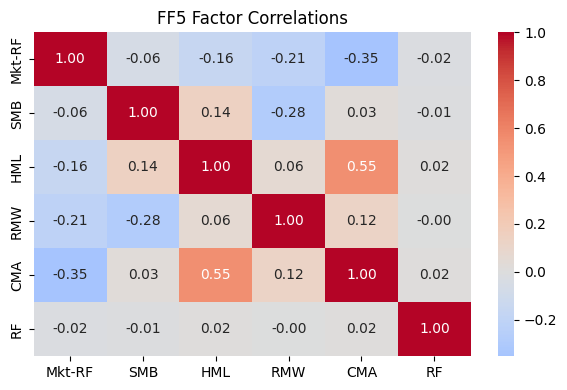

In [188]:
# === Step 5 (optional): Plot heatmaps ===
plt.figure(figsize=(6, 4))
sns.heatmap(corr_ff5, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("FF5 Factor Correlations")
plt.tight_layout()
plt.show()

In [189]:
# === Step 3: Compute covariance matrices ===
cov_ff5 = ff5_factors.cov()
cov_ff5 = cov_ff5.round(3)
# === Step 4: Print results ===
print("=== FF3 Covariance Matrix ===")
print(cov_ff5.round(3))

=== FF3 Covariance Matrix ===
        Mkt-RF    SMB    HML    RMW    CMA
Mkt-RF   1.040 -0.032 -0.096 -0.086 -0.137
SMB     -0.032  0.303  0.046 -0.062  0.006
HML     -0.096  0.046  0.343  0.014  0.123
RMW     -0.086 -0.062  0.014  0.161  0.019
CMA     -0.137  0.006  0.123  0.019  0.145


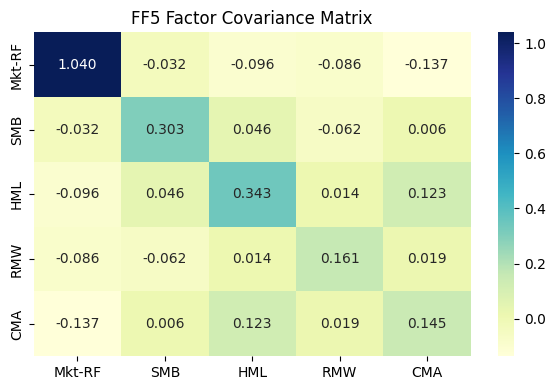

In [190]:
# === Step 5: Optional heatmap visualization ===
plt.figure(figsize=(6, 4))
sns.heatmap(cov_ff5, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("FF5 Factor Covariance Matrix")
plt.tight_layout()
plt.show()

## Correlation and covariance for change in factor returns

In [191]:
delta_ff5 =ff5_factors.diff().dropna()
corr_delta_ff5 = delta_ff5.corr()
corr_delta_ff5

,Mkt-RF,SMB,HML,RMW,CMA
Mkt-RF,1.000000,-0.114953,-0.121490,-0.208094,-0.317673
SMB,-0.114953,1.000000,0.175804,-0.285322,0.047686
HML,-0.121490,0.175804,1.000000,0.041299,0.508854
RMW,-0.208094,-0.285322,0.041299,1.000000,0.133749
CMA,-0.317673,0.047686,0.508854,0.133749,1.000000


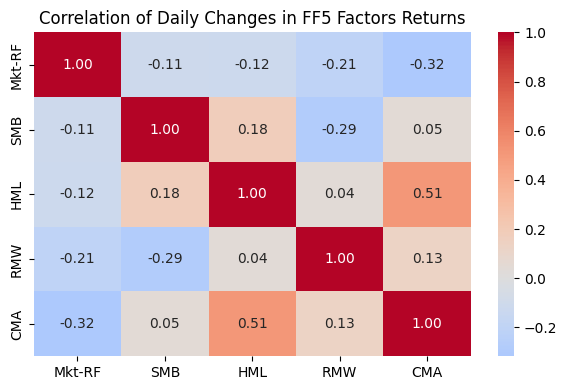

In [192]:

# === Step : Plot heatmaps ===
plt.figure(figsize=(6, 4))
sns.heatmap(corr_delta_ff5, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of Daily Changes in FF5 Factors Returns")
plt.tight_layout()
plt.show()

In [193]:
# === Step 3: Compute covariance matrices ===
cov_delta_ff5 = delta_ff5.cov()
cov_ff5 = cov_ff5.round(3)
# === Step 4: Print results ===
print("=== FF3 Covariance Matrix ===")
print(cov_delta_ff5.round(3))

=== FF3 Covariance Matrix ===
        Mkt-RF    SMB    HML    RMW    CMA
Mkt-RF   2.041 -0.126 -0.137 -0.158 -0.229
SMB     -0.126  0.586  0.106 -0.116  0.018
HML     -0.137  0.106  0.623  0.017  0.202
RMW     -0.158 -0.116  0.017  0.282  0.036
CMA     -0.229  0.018  0.202  0.036  0.254


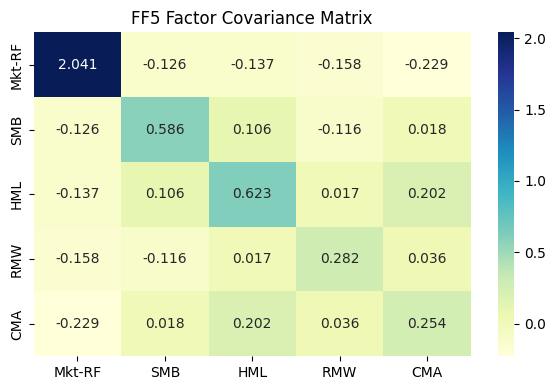

In [194]:
# === Step 5: Optional heatmap visualization ===
plt.figure(figsize=(6, 4))
sns.heatmap(cov_delta_ff5, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("FF5 Factor Covariance Matrix")
plt.tight_layout()
plt.show()

# Step 6

### For Tesla stock

In [195]:
# Retrieve specific model rows
ff3_row = metrics_ff3.loc["ols_simple_ff3"]
ff5_row = metrics_ff5.loc["ols_simple_ff5"]
b3 = betas_ff3.loc["ols_simple_ff3"]
b5 = betas_ff5.loc["ols_simple_ff5"]

# Factor exposures
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
factor_table = pd.DataFrame({
    'FF3 Beta': [b3.get(f, '—') for f in factors],
    'FF5 Beta': [b5.get(f, '—') for f in factors]
}, index=factors)

# Model performance
performance_table = pd.DataFrame({
    'FF3': [ff3_row['r2'], ff3_row['rmse']],
    'FF5': [ff5_row['r2'], ff5_row['rmse']]
}, index=['Adj R²', 'RMSE'])

display(factor_table)
display(performance_table)


,FF3 Beta,FF5 Beta
Mkt-RF,0.017012,0.014044
SMB,0.003461,-0.000302
HML,-0.006765,0.001579
RMW,NaN,-0.006270
CMA,NaN,-0.008954


,FF3,FF5
Adj R²,0.273955,0.252774
RMSE,0.036229,0.036754


### For equally weighted portfolio

In [196]:
# Retrieve specific model rows
ff3_row = metrics_ff3_2.loc["ols_simple_ff3"]
ff5_row = metrics_ff5_2.loc["ols_simple_ff5"]
b3 = betas_ff3_2.loc["ols_simple_ff3"]
b5 = betas_ff5_2.loc["ols_simple_ff5"]

# Factor exposures
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
factor_table = pd.DataFrame({
    'FF3 Beta': [b3.get(f, '—') for f in factors],
    'FF5 Beta': [b5.get(f, '—') for f in factors]
}, index=factors)

# Model performance
performance_table = pd.DataFrame({
    'FF3': [ff3_row['r2'], ff3_row['rmse']],
    'FF5': [ff5_row['r2'], ff5_row['rmse']]
}, index=['Adj R²', 'RMSE'])

display(factor_table)
display(performance_table)


,FF3 Beta,FF5 Beta
Mkt-RF,0.014299,0.013521
SMB,-0.001454,-0.002003
HML,-0.004224,-0.002105
RMW,NaN,-0.000636
CMA,NaN,-0.002800


,FF3,FF5
Adj R²,0.545252,0.587546
RMSE,0.010873,0.010355


# Step 7

In [197]:
# === Step 1: Select 5 stocks and download data ===
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
start = ff5.index[-1] - pd.Timedelta(days=3*365)
end = ff5.index[-1]
data = yf.download(tickers, start=start, end=end)['Close']
returns = data.pct_change().dropna()


[*********************100%***********************]  5 of 5 completed


In [198]:
returns.head()

Ticker,AAPL,AMZN,GOOG,MSFT,TSLA
Date,,,,,
2022-01-04,-0.012692,-0.016916,-0.004535,-0.017147,-0.041833
2022-01-05,-0.026600,-0.018893,-0.046830,-0.038388,-0.053471
2022-01-06,-0.016693,-0.006711,-0.000745,-0.007902,-0.021523
2022-01-07,0.000988,-0.004288,-0.003973,0.000510,-0.035447
2022-01-10,0.000116,-0.006570,0.011456,0.000732,0.030342


In [199]:
mean_returns

,0
Ticker,
AAPL,0.000601
AMZN,0.000640
GOOG,0.000596
MSFT,0.000502
TSLA,0.000799


In [200]:
# === Step 2: Compute mean and covariance of returns ===
mean_returns = returns.mean()
cov_matrix = returns.cov()

print ("Mean Returns:\n", mean_returns, "\n")
print ("Covariance Matrix:\n", cov_matrix, "\n")

Mean Returns:
 Ticker
AAPL    0.000601
AMZN    0.000640
GOOG    0.000596
MSFT    0.000502
TSLA    0.000799
dtype: float64 

Covariance Matrix:
 Ticker      AAPL      AMZN      GOOG      MSFT      TSLA
Ticker                                                  
AAPL    0.000292  0.000232  0.000219  0.000203  0.000329
AMZN    0.000232  0.000584  0.000326  0.000289  0.000419
GOOG    0.000219  0.000326  0.000426  0.000249  0.000321
MSFT    0.000203  0.000289  0.000249  0.000302  0.000281
TSLA    0.000329  0.000419  0.000321  0.000281  0.001492 



In [201]:
# === Step 3: Define portfolio functions ===
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.01/252):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol  # Negative for minimization

# === Step 4: Optimization ===
num_assets = len(tickers)
bounds = [(-1.0, 1.0)] * num_assets  # allow short selling
initial_weights = np.ones(num_assets) / num_assets
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

result = minimize(negative_sharpe, initial_weights,
                  args=(mean_returns, cov_matrix),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

optimal_weights = result.x

# === Step 5: Efficient Frontier ===
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)


In [202]:
target_vols = []
port_weights = []

for r in target_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - r}
    )
    result = minimize(lambda w: np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))),
                      initial_weights,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints)

    if result.success:
        port_weights.append(result.x)
        _, vol = portfolio_performance(result.x, mean_returns, cov_matrix)
        target_vols.append(vol)






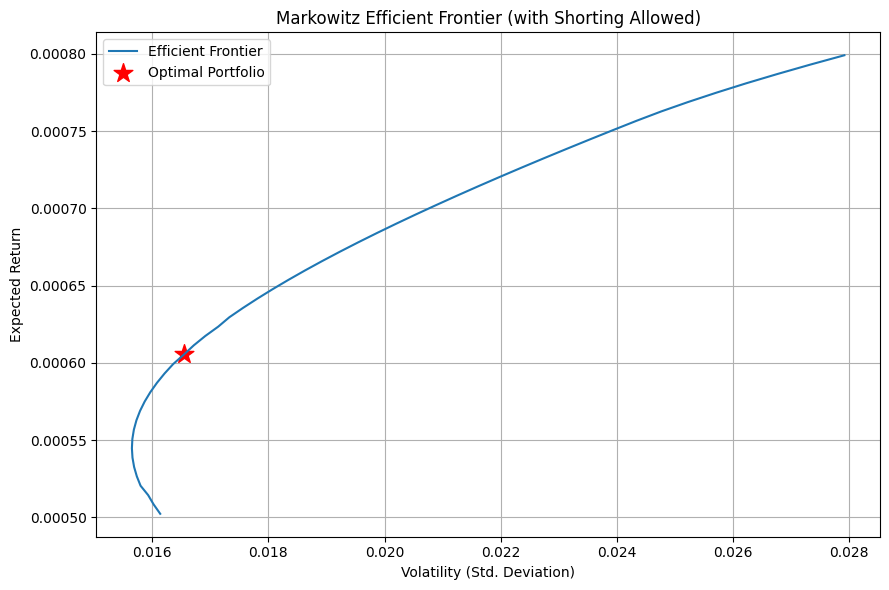

In [203]:
# === Step 6: Plot Efficient Frontier and Optimal Portfolio ===
plt.figure(figsize=(9, 6))
plt.plot(target_vols, target_returns, label='Efficient Frontier')
opt_ret, opt_vol = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
plt.scatter(opt_vol, opt_ret, marker='*', color='r', s=200, label='Optimal Portfolio')
plt.title('Markowitz Efficient Frontier (with Shorting Allowed)')
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [204]:
# === Step 7: Print optimal weights ===
opt_df = pd.DataFrame({'Stock': tickers, 'Weight': optimal_weights})
print("\n=== Optimal Portfolio Weights ===")
print(opt_df)


=== Optimal Portfolio Weights ===
  Stock    Weight
0  AAPL  0.676217
1  MSFT  0.104588
2  GOOG  0.153145
3  AMZN  0.038873
4  TSLA  0.027178


In [205]:
opt_df

,Stock,Weight
0,AAPL,0.676217
1,MSFT,0.104588
2,GOOG,0.153145
3,AMZN,0.038873
4,TSLA,0.027178


In [206]:
# Compute expected market return and std dev
market_ret = ff5['Mkt-RF']
rf_daily = ff5['RF'].mean()
E_rm = market_ret.mean()
std_rm = market_ret.std()
print ("------ Market Return (Mkt-Rf)-----")
print ("Mean Return:", round(E_rm,3))
print ("Standard Deviation:", round(std_rm,3))

------ Market Return (Mkt-Rf)-----
Mean Return: 0.028
Standard Deviation: 1.02


In [207]:
portfolio_returns = returns.dot(optimal_weights)
E_rp = portfolio_returns.mean()
std_rp = portfolio_returns.std()
print ("------ Portfolio Return (Return*weight)-----")
print ("Mean Return:", round(E_rp,3))
print ("Standard Deviation:", round(std_rp,3))

------ Portfolio Return (Return*weight)-----
Mean Return: 0.001
Standard Deviation: 0.017




> Add blockquote


## Step 7.b :Markowitz portfolio optimization and FF3


In [208]:
df5.columns

Index(['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'DGS10_chg', 'VIXCLS_chg',
       'DGS2_chg', 'DCOILWTICO_chg', 'TermSpread_chg', 'Excess Return'],
      dtype='object')

In [209]:
portfolio_returns = returns.dot(optimal_weights)
df5=pd.DataFrame(df5)
ff=df2[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF','DGS10_chg','VIXCLS_chg',\
        'DGS2_chg', 'DCOILWTICO_chg', 'TermSpread_chg']]
ff=ff[start:end]
ff=pd.DataFrame(ff)
ff.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
2022-01-05,-2.28,-0.94,2.59,1.39,1.25,0.0,0.0005,0.0282,0.0006,0.0083,-0.0001
2022-01-06,0.00,0.38,1.75,-0.56,-0.01,0.0,0.0002,-0.0012,0.0005,0.0164,-0.0003
2022-01-07,-0.48,-0.96,2.02,-0.12,0.85,0.0,0.0003,-0.0085,-0.0001,-0.0047,0.0004
2022-01-10,-0.15,-0.30,-0.28,-0.05,-0.37,0.0,0.0002,0.0064,0.0005,-0.0089,-0.0003
2022-01-11,1.10,-0.20,-0.28,-1.25,0.37,0.0,-0.0003,-0.0099,-0.0002,0.0306,-0.0001


In [210]:
# === Step 4: Align and merge ===
portfolio_returns.name = 'Portfolio'
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
df7 = pd.merge(portfolio_returns,ff, left_index=True, right_index=True).dropna()
df7['Excess Return'] = df7['Portfolio'] - df7['RF']
df7.drop(['Portfolio', 'RF'], axis=1, inplace=True)
df7.head()

,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg,Excess Return
2022-01-05,-2.28,-0.94,2.59,1.39,1.25,0.0005,0.0282,0.0006,0.0083,-0.0001,-0.030080
2022-01-06,0.00,0.38,1.75,-0.56,-0.01,0.0002,-0.0012,0.0005,0.0164,-0.0003,-0.012996
2022-01-07,-0.48,-0.96,2.02,-0.12,0.85,0.0003,-0.0085,-0.0001,-0.0047,0.0004,-0.001332
2022-01-10,-0.15,-0.30,-0.28,-0.05,-0.37,0.0002,0.0064,0.0005,-0.0089,-0.0003,0.001999
2022-01-11,1.10,-0.20,-0.28,-1.25,0.37,-0.0003,-0.0099,-0.0002,0.0306,-0.0001,0.015704


In [211]:
# === Step 5: Run OLS regression on FF3 ===
X = sm.add_constant(df7[['Mkt-RF', 'SMB', 'HML', 'DGS10_chg','VIXCLS_chg',\
        'DGS2_chg', 'DCOILWTICO_chg', 'TermSpread_chg']])
y = df7['Excess Return']

# scaler = StandardScaler().fit(X)
# X[:]    = scaler.transform(X)

split_ind=int(0.8*len(X))
X_train = X.iloc[:split_ind]
X_test = X.iloc[split_ind:]

y_train = y.iloc[:split_ind]
y_test = y.iloc[split_ind:]

len(X_test)

150

In [212]:
model7b = sm.OLS(y_train, X_train).fit()

# === Step 6: Output results ===
print(model7b.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     155.6
Date:                Thu, 01 May 2025   Prob (F-statistic):          1.02e-129
Time:                        16:16:49   Log-Likelihood:                 1848.2
No. Observations:                 600   AIC:                            -3680.
Df Residuals:                     592   BIC:                            -3645.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0138      0.000    -29.

### β_Mkt-RF: Sensitivity to the market.

### β_SMB: Exposure to size (small vs big).

### β_HML: Exposure to value (high book-to-market vs low).

### If β_Mkt-RF ≈ 1 → behaves like the market.

### If β_SMB > 0 → tilted toward small-cap stocks.

### If β_HML < 0 → tilted toward growth stocks.



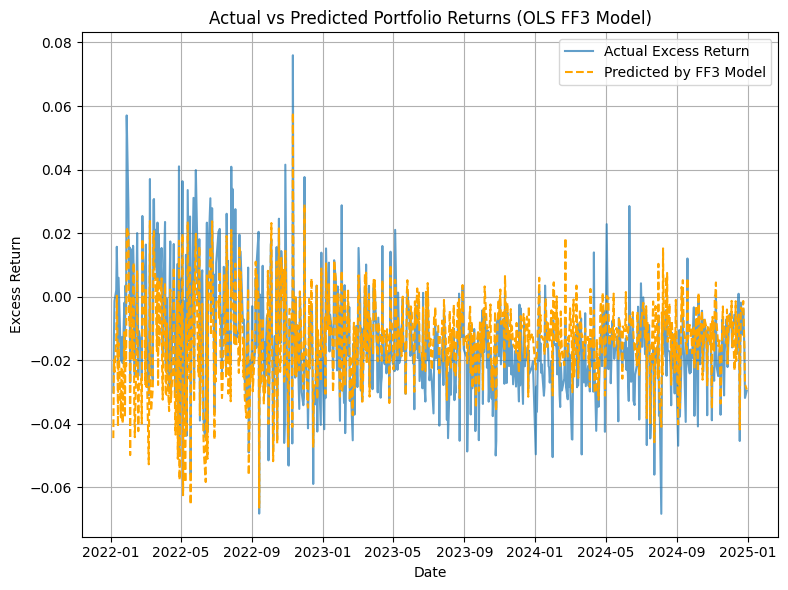

In [213]:
y_pred_X = model7b.predict(X)

# === Step 5: Plot Actual vs Predicted ===
plt.figure(figsize=(8, 6))
plt.plot(df7.index, df7['Excess Return'], label='Actual Excess Return', alpha=0.7)
plt.plot(df7.index, y_pred_X, label='Predicted by FF3 Model', linestyle='--', color='orange')
plt.title("Actual vs Predicted Portfolio Returns (OLS FF3 Model)")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [214]:


# Predict on test set (assuming your model is called `model`)
y_pred_test = model7b.predict(X_test)

# Compute metrics
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print ("----Test Data results for FF3-----")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


----Test Data results for FF3-----
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.3546


In [215]:
print("\n=== Overall Set Metrics ===")
print(f" R²: {r2_score(df7['Excess Return'], y_pred_X):.4f}, \
  MSE: {mean_squared_error(df7['Excess Return'], y_pred_X):.6f}")




=== Overall Set Metrics ===
 R²: 0.6213,   MSE: 0.000120


In [216]:
methods        = ['ols','huber','ridge','lasso','elasticnet']
regimes        = ['simple','rolling']
macro_options  = [False, True]

results = []

for method in methods:
    for regime in regimes:
        for macro in macro_options:
            name = f"{method}_{regime}_ff3" + ("_macro" if macro else "")

            # call your unified function
            betas_all, rmse, r2 = regression(
                df7,
                method               = method,
                factors              = 'ff3',
                macro                = macro,
                train_test_division  = regime,
                train_test_ratio     = 0.8,
                window               = 60,
                scale                = True,
                savgol_window        = 60,
                savgol_polyorder     = 3,
                # you can also pass reg_params={'ridge':{'alpha':2.0},...} here if desired
            )

            # for "rolling", extract just the last row of betas
            if regime == 'rolling':
                betas = betas_all.iloc[-1]
            else:
                betas = betas_all

            results.append((name, betas, rmse, r2))

# now unpack into DataFrames
names_2, betas_list_2, rmses_2, r2s_2 = zip(*results)

# 1) betas_df: each row = one model, columns = factors
betas_ff3_2 = pd.DataFrame(betas_list_2, index=names_2)

# 2) metrics_df: RMSE & R²
metrics_ff3_2 = pd.DataFrame({
    'rmse': rmses_2,
    'r2':   r2s_2
}, index=names_2).sort_values('r2', ascending=False)

# inspect
print(betas_ff3_2.shape)    # (20, p)
print(metrics_ff3_2.shape)  # (20, 2)
metrics_ff3_2.head()

(20, 10)
(20, 2)


,rmse,r2
huber_rolling_ff3_macro,0.009369,0.460332
ridge_rolling_ff3,0.009402,0.456518
ols_rolling_ff3,0.009512,0.443713
huber_rolling_ff3,0.009531,0.441576
ridge_rolling_ff3_macro,0.009809,0.408478


In [217]:
betas_ff3_2.head(5)

,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
ols_simple_ff3,0.013205,-0.001976,-0.002817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ols_simple_ff3_macro,0.014257,-0.001082,-0.004750,0.001428,0.001816,0.000198,0.000794,0.000337,0.000313,-0.000269
ols_rolling_ff3,0.011334,0.002146,-0.005603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ols_rolling_ff3_macro,0.011241,0.001244,-0.007393,0.003626,0.002724,-0.001601,-0.000983,-0.002401,-0.000729,0.001651
huber_simple_ff3,0.012973,-0.001755,-0.003235,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 7.c :Markowitz portfolio optimization and FF5


In [218]:
# # === Step 3: Merge returns with FF5 data ===
# #portfolio_returns = portfolio_returns.to_frame(name='Portfolio')
# portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
# df = pd.merge(portfolio_returns, ff5, left_index=True, right_index=True).dropna()
# # df['Excess Return'] = df['Portfolio'] - df['RF']


In [219]:
# === Step 4: Run OLS regression with FF5 ===
X8 = sm.add_constant(df7[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'DGS10_chg',\
        'VIXCLS_chg','DGS2_chg', 'DCOILWTICO_chg', 'TermSpread_chg']])
y8 = df7['Excess Return']

# scaler = StandardScaler().fit(X8)
# X8[:]    = scaler.transform(X8)

split_ind=int(0.8*len(X))
X_train8 = X8.iloc[:split_ind]
X_test8 = X8.iloc[split_ind:]

y_train8 = y8.iloc[:split_ind]
y_test8 = y8.iloc[split_ind:]

len(X_test8)


150

In [220]:
model_ff5 = sm.OLS(y_train8, X_train8).fit()

# === Step 5: Output the regression summary ===
print(model_ff5.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     124.4
Date:                Thu, 01 May 2025   Prob (F-statistic):          4.42e-130
Time:                        16:17:19   Log-Likelihood:                 1854.2
No. Observations:                 600   AIC:                            -3688.
Df Residuals:                     590   BIC:                            -3644.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0138      0.000    -30.

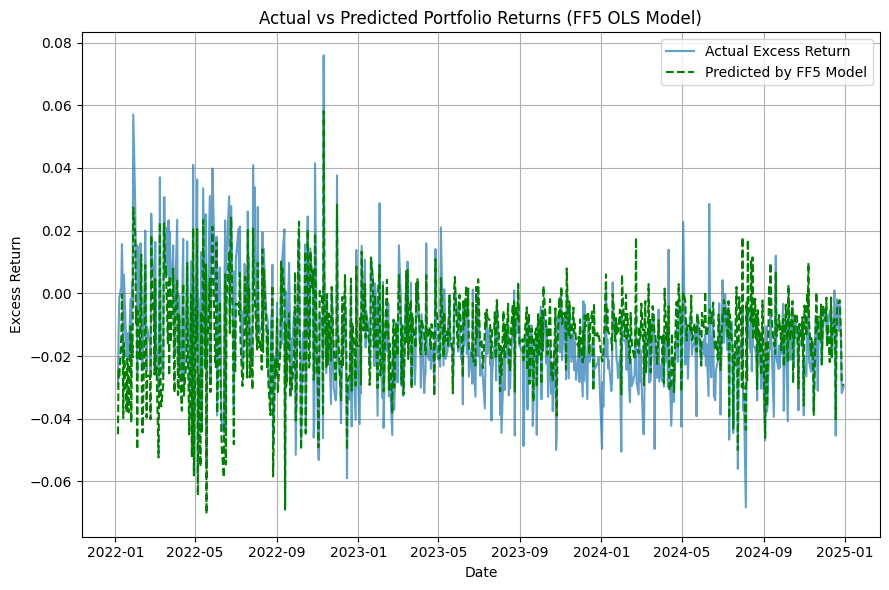

In [221]:
# === Step 6: Plot Actual vs Predicted ===
y_pred_X = model_ff5.predict(X8)
plt.figure(figsize=(9, 6))
plt.plot(df7.index, df7['Excess Return'], label='Actual Excess Return', alpha=0.7)
plt.plot(df7.index, y_pred_X, label='Predicted by FF5 Model', linestyle='--', color='green')
plt.title("Actual vs Predicted Portfolio Returns (FF5 OLS Model)")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [222]:

# Predict on test set (assuming your model is called `model`)
y_pred8 = model_ff5.predict(X_test8)

# Compute metrics
mse = mean_squared_error(y_test8, y_pred8)
r2 = r2_score(y_test8, y_pred8)

print ("----Test Data results for FF5-----")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


----Test Data results for FF5-----
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.3035


In [223]:
print("\n=== Overall Set Metrics ===")
print(f" R²: {r2_score(df7['Excess Return'], y_pred_X):.4f}, \
  MSE: {mean_squared_error(df7['Excess Return'], y_pred_X):.6f}")




=== Overall Set Metrics ===
 R²: 0.6223,   MSE: 0.000120


In [224]:
# first, your unified regression() from before
# from your_module import regression

methods        = ['ols','huber','ridge','lasso','elasticnet']
regimes        = ['simple','rolling']
macro_options  = [False, True]

results = []

for method in methods:
    for regime in regimes:
        for macro in macro_options:
            name = f"{method}_{regime}_ff5" + ("_macro" if macro else "")

            # call your unified function
            betas_all, rmse, r2 = regression(
                df7,
                method               = method,
                factors              = 'ff5',
                macro                = macro,
                train_test_division  = regime,
                train_test_ratio     = 0.8,
                window               = 60,
                scale                = True,
                savgol_window        = 11,
                savgol_polyorder     = 3,
                # you can also pass reg_params={'ridge':{'alpha':2.0},...} here if desired
            )

            # for "rolling", extract just the last row of betas
            if regime == 'rolling':
                betas = betas_all.iloc[-1]
            else:
                betas = betas_all

            results.append((name, betas, rmse, r2))

# now unpack into DataFrames
names_2, betas_list_2, rmses_2, r2s_2 = zip(*results)

# 1) betas_df: each row = one model, columns = factors
betas_ff5_2 = pd.DataFrame(betas_list_2, index=names_2)

# 2) metrics_df: RMSE & R²
metrics_ff5_2 = pd.DataFrame({
    'rmse': rmses_2,
    'r2':   r2s_2
}, index=names_2).sort_values('r2', ascending=False)

# inspect
print(betas_ff5_2.shape)    # (20, p)
print(metrics_ff5_2.shape)  # (20, 2)
betas_ff5_2.head()
metrics_ff5_2.head()


(20, 10)
(20, 2)


,rmse,r2
ridge_rolling_ff5,0.009044,0.497169
huber_rolling_ff5,0.009068,0.494465
ols_rolling_ff5,0.009284,0.470169
huber_rolling_ff5_macro,0.009323,0.465664
ridge_rolling_ff5_macro,0.009741,0.416634


In [225]:
betas_ff5_2.head()

,Mkt-RF,SMB,HML,RMW,CMA,DGS10_chg,VIXCLS_chg,DGS2_chg,DCOILWTICO_chg,TermSpread_chg
ols_simple_ff5,0.013775,-0.001184,-0.004430,0.001364,0.001647,NaN,NaN,NaN,NaN,NaN
ols_simple_ff5_macro,0.014257,-0.001082,-0.004750,0.001428,0.001816,0.000198,0.000794,0.000337,0.000313,-0.000269
ols_rolling_ff5,0.012580,0.003217,-0.006658,0.003617,0.001595,NaN,NaN,NaN,NaN,NaN
ols_rolling_ff5_macro,0.011241,0.001244,-0.007393,0.003626,0.002724,-0.001601,-0.000983,-0.002401,-0.000729,0.001651
huber_simple_ff5,0.013280,-0.000845,-0.004442,0.001660,0.000711,NaN,NaN,NaN,NaN,NaN
